# 20Hz VC: 과거 명령이 다음 전류 예측을 개선하는가

## 요약
양성 표적의 같은 명령 뒤 시행4에서 초기 RMSE는 baseline 2.2428pA, 이력 2.2082pA였다. 회복에서는 각각 2.8144, 2.9262pA로 개선되지 않았다. 다른 명령 조건에서도 이력의 일관된 우위가 없었다. 네 선택 모두50ms 후보 하한이며 생리적 시정수 추정이 아니다.

## 질문과 방법
같은 세포의 직전 전류로 기준선을 정한 뒤 source 명령에 맞춘 반응을 예측한다.
Source 전압/AP는 관측하지 않았으므로 명령 이력과 시냅스 효능을 동일시하지 않는다.
파형을 먼저 살펴본 후향적 분석이며 독립적인 새 실험 검증이 아니다.

- 적합: source 120mV인 시행2·3의 초기8개 pulse만 사용한다.
- 평가: 같은 시행의 회복4개, 뒤 시행4, 뒤 시행5·6, 앞의60mV 시행0·1을 구별한다.
- 시행5·6에서 자기 명령150mV 변경은 AD8/device4에만 해당한다. AD2는120mV를 유지한다.
- 각 pulse의 [−10,−2)ms 관측만으로 일정 수준 또는 선형 추세 기준선을 만든다.
  이전 pulse의 늦은 반응은 다음 기준선에 포함될 수 있다. 두 정책을 별도로 보고한다.
- 점수는 명령 후[2,40)ms의0.5ms 평균 전류다. [0,2)ms 경계 반응은 제외한다.
  이 제외로 모든 측정 artifact가 제거됐다고 주장하지 않는다.

현재 명령을 $u_n=\Delta V_n/0.12\mathrm{V}$라 두고
$h_0=0$, $h_n=e^{-\Delta t_n/\tau}(h_{n-1}+u_{n-1})$로 둔다.
고정 모형은 $B_n(r)+u_n a(r)$, 이력 모형은
$B_n(r)+u_n[a(r)+h_n b(r)]$다. 각 lag의 template는 선형 최소제곱으로 적합한다.
시행 간 이력은0으로 초기화하는 후보 모형이며, 명령을 절반으로 줄이면 고정 항은1/2,
이력 항은1/4이 된다는 수송 가정을 포함한다.

$\tau$ 후보는50·150·500·1500ms뿐이다. 시행2·3 중 하나로 적합하고 다른 하나의 초기8개를
평가하는 내부 교차검증으로 선택한 후 둘에 다시 적합한다. 회복·평가 시행은 선택에 쓰지 않는다.
같은 세포의 시행과 pulse를 독립 동물 표본으로 세지 않는다.

## 입력과 관측 조건


In [1]:
import hashlib,json
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image,display
root = next(p for p in [Path.cwd(),*Path.cwd().parents]
            if (p/'verify/Q-NPF-04/allen_synphys/vc20hz_command_history_result.json').exists())
folder = root/'verify/Q-NPF-04/allen_synphys'
figures = folder/'figures'
figures.mkdir(exist_ok=True)
def digest(path):
    with Path(path).open('rb') as stream:
        return hashlib.file_digest(stream,'sha256').hexdigest()
result_path = folder/'vc20hz_command_history_result.json'
result = json.loads(result_path.read_text(encoding='utf-8'))
assert digest(folder/'vc20hz_command_history.py')==result['source_sha256']
assert digest(root/'tests/test_vc20hz_command_history.py')==result['test_sha256']
assert digest(root/result['arrays']['path'])==result['arrays']['sha256']
assert digest(folder/'vc20hz_measurement_state_result.json')==result['inputs']['measurement_state_sha256']
raw_metadata = json.loads((folder/'vc20hz_source_inputs_result.json').read_text(encoding='utf-8'))
assert digest(folder/'vc20hz_source_inputs_result.json')==result['inputs']['metadata_sha256']
assert digest(root/raw_metadata['arrays']['path'])==raw_metadata['arrays']['sha256']
with np.load(root/result['arrays']['path'],allow_pickle=False) as archive:
    z = {k:archive[k] for k in archive.files}
with np.load(root/raw_metadata['arrays']['path'],allow_pickle=False) as archive:
    raw = {k:archive[k] for k in archive.files}
comp = json.loads((folder/'vc20hz_compensation_result.json').read_text(encoding='utf-8'))
assert digest(folder/'vc20hz_compensation.py')==comp['source_sha256']
assert digest(root/'tests/test_vc20hz_compensation.py')==comp['test_sha256']
assert len(comp['records'])==21
assert all(r['rs_compensation_enabled'] is False and r['whole_cell_compensation_enabled'] is False for r in comp['records'])
print('Frozen prediction result SHA256:',digest(result_path))
print('14 target-sweeps; 7 repetitions of the same source/targets; 84 pulses per target.')
print('Rs and whole-cell compensation: Off in all 21 acquisition records.')
print('Numerical fast/slow capacitances are compensation settings, not measured membrane C.')
plt.rcParams.update({'font.size':10,'axes.spines.top':False,'axes.spines.right':False})


Frozen prediction result SHA256: cd5db80771b16d53e042643768ff2d93876982397c606791e2a7a5f9b40d5991
14 target-sweeps; 7 repetitions of the same source/targets; 84 pulses per target.
Rs and whole-cell compensation: Off in all 21 acquisition records.
Numerical fast/slow capacitances are compensation settings, not measured membrane C.


## 1. 측정 파형과 명령 경계
왼쪽은100kHz 원표본의 pulse 평균이며 큰 경계 반응을 드러낸다. 오른쪽은 점수화한
0.5ms 평균이다. 각 선은 한 시행의12개 pulse 평균이며 신뢰구간이 아니다.
패널마다 세로축 범위가 다르다. AD8은 보고된 연결의 표적, AD2는 보고된 연결이 없는 표적이다.
이 명칭은 전류 부호나 억제성 연결을 뜻하지 않는다.


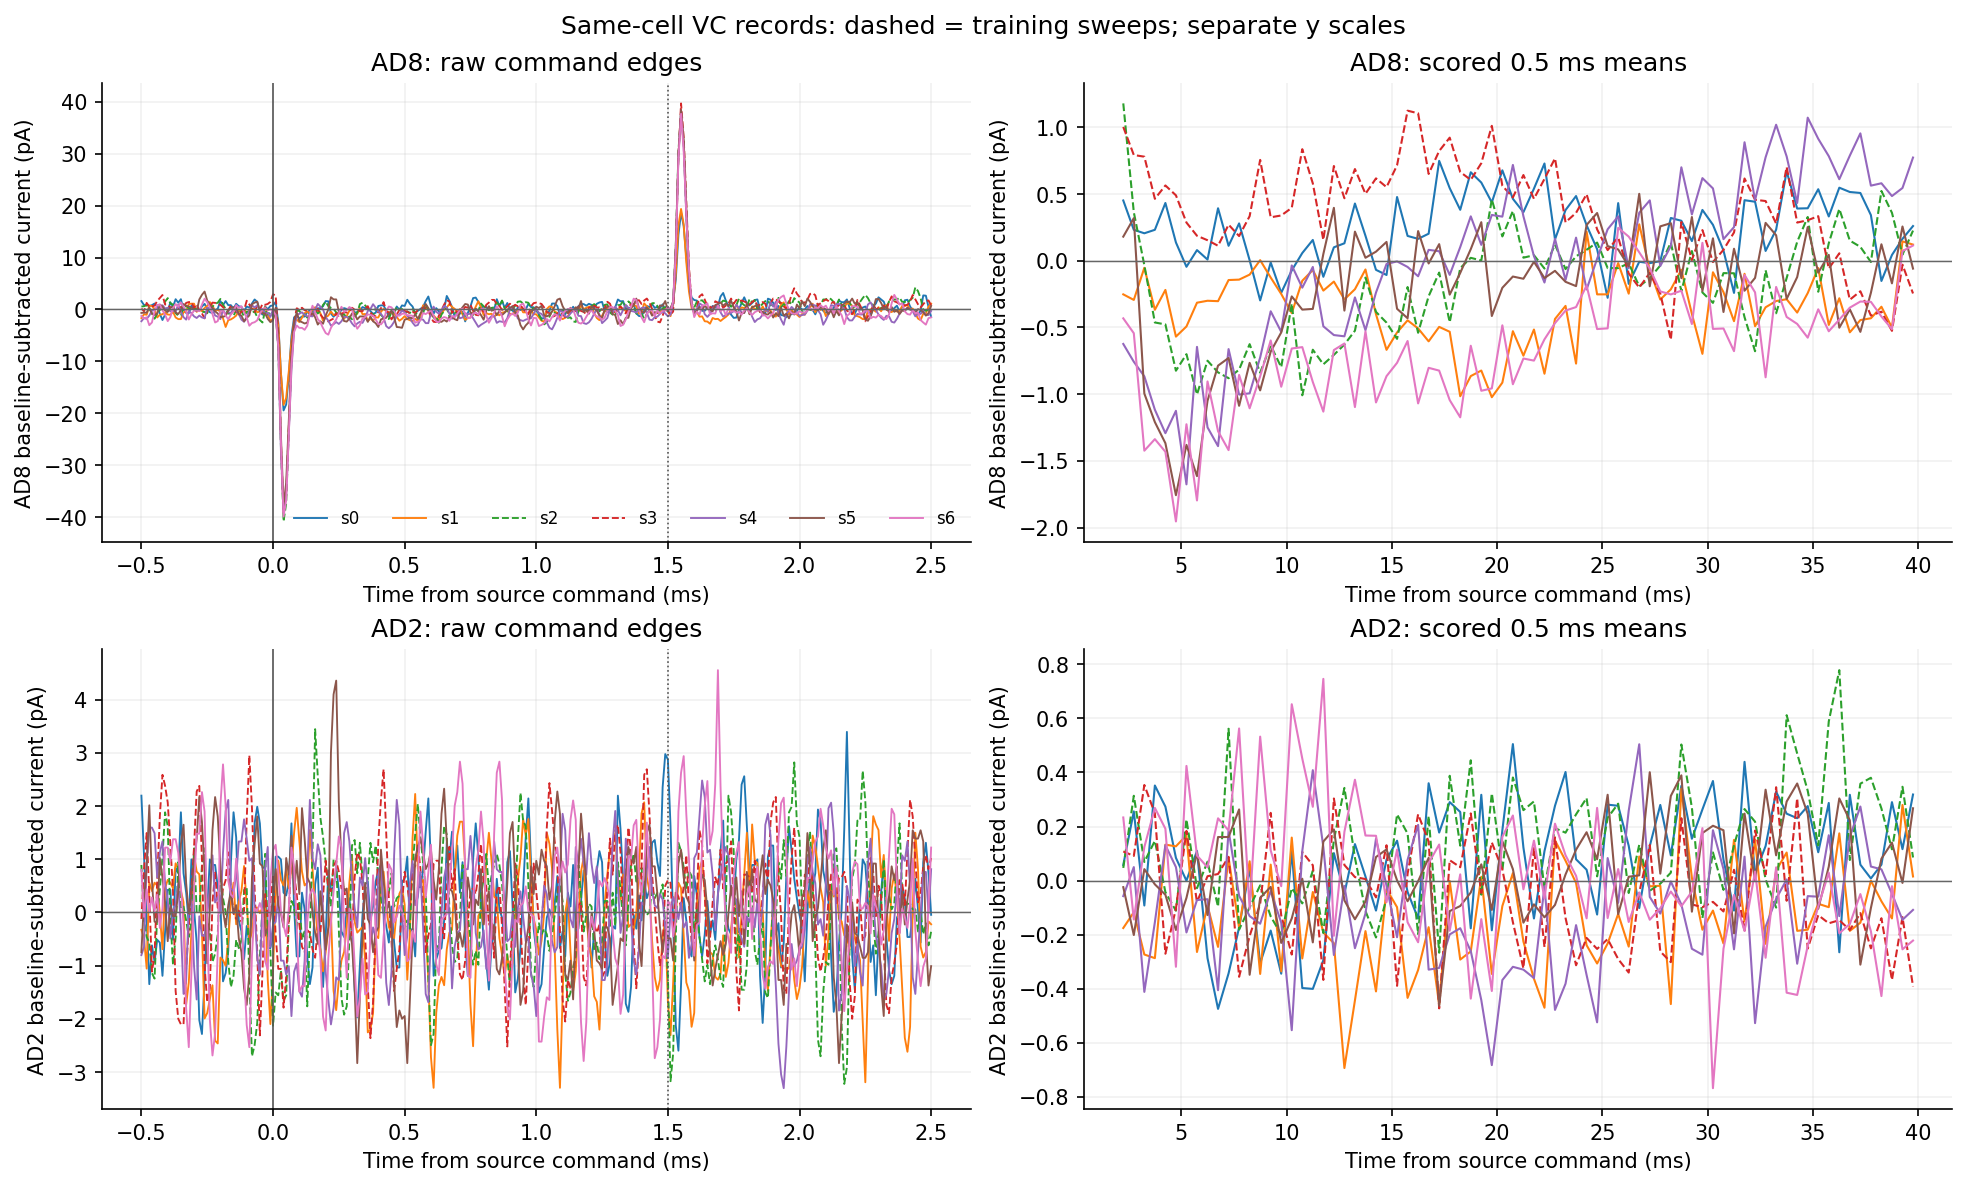

In [2]:
fig,axes = plt.subplots(2,2,figsize=(13,7.8),layout='constrained')
colors = plt.cm.tab10(np.arange(7))
for row,(target,channel) in enumerate((('positive','AD8'),('negative','AD2'))):
    for sweep in range(7):
        key = target+'_s'+str(sweep)
        current = raw[f's{sweep}_{channel}_A']*1e12
        pulses = z[key+'_events']
        prefix = np.stack([current[p-1000:p-200] for p in pulses]).mean(axis=1)
        offsets = np.arange(-50,251)
        edge = np.stack([current[p+offsets] for p in pulses])-prefix[:,None]
        delayed = z[key+'_observed']-z[key+'_pre'].mean(axis=1)[:,None]
        style = '--' if sweep in (2,3) else '-'
        axes[row,0].plot(offsets/100,edge.mean(axis=0),color=colors[sweep],ls=style,lw=.9,label=f's{sweep}')
        axes[row,1].plot(2.245+np.arange(76)*.5,delayed.mean(axis=0),color=colors[sweep],ls=style,lw=1,label=f's{sweep}')
    for ax in axes[row]:
        ax.axhline(0,color='#666666',lw=.7)
        ax.set_xlabel('Time from source command (ms)')
        ax.set_ylabel(channel+' baseline-subtracted current (pA)')
        ax.grid(alpha=.18)
    axes[row,0].axvline(0,color='#555555',lw=.8)
    axes[row,0].axvline(1.5,color='#555555',lw=.8,ls=':')
    axes[row,0].set_title(channel+': raw command edges')
    axes[row,1].set_title(channel+': scored 0.5 ms means')
axes[0,0].legend(ncol=7,fontsize=8,frameon=False)
fig.suptitle('Same-cell VC records: dashed = training sweeps; separate y scales')
path = figures/'vc20hz_observed_currents.png'
fig.savefig(path,dpi=150,bbox_inches='tight')
display(Image(filename=str(path)))
plt.close(fig)


## 2. 저장 예측의 독립 점수 검산
모형을 다시 적합하지 않는다. 모든 candidate·시행·창의 RMSE와 bias를 저장 배열에서
계산하고 JSON과 비교한다. 집계는 시행별 MSE를 같은 비중으로 평균한 뒤 제곱근을 취한다.
초기8개와 회복4개는 별도 점수다. Training/initial은 적합값이고 training/recovery만
같은 시행 안에서 남겨 둔 반응이다.


In [3]:
recomputed = {}
for r in result['per_sweep']:
    key = r['target']+'_s'+str(r['sweep'])
    prediction = z[key+'_'+r['baseline']+'_'+r['method']]
    error = prediction-z[key+'_observed']
    pulses = slice(0,8) if r['region']=='initial' else slice(8,12)
    columns = {'all':slice(None),'early':slice(0,16),'late':slice(16,None)}[r['window']]
    e = error[pulses,columns]
    mse,bias = float(np.mean(e**2)),float(e.mean())
    np.testing.assert_allclose([mse,bias],[r['mse_pA2'],r['bias_pA']],rtol=1e-12,atol=1e-12)
    key = tuple(r[k] for k in ('target','baseline','method','sweep','region','window'))
    recomputed[key] = (mse,bias)
for r in result['summary']:
    values = [recomputed[r['target'],r['baseline'],r['method'],s,r['region'],r['window']] for s in r['sweeps']]
    np.testing.assert_allclose([np.sqrt(np.mean([x[0] for x in values])),np.mean([x[1] for x in values])],
                              [r['rmse_pA'],r['bias_pA']],rtol=1e-12,atol=1e-12)
print('Checked per-sweep scores:',len(recomputed),'and grouped scores:',len(result['summary']))
for fit in result['fits']:
    print(fit['target'],fit['baseline'],'selected tau(ms)=',fit['tau_s']*1000,
          'grid boundary=',fit['tau_at_grid_boundary'],
          'CV MSE=',[round(r['cv_mse_pA2'],5) for r in fit['inner_cv']])
def score(target,policy,method,cohort,region):
    return next(r['rmse_pA'] for r in result['summary'] if (r['target'],r['baseline'],r['method'],r['cohort'],r['region'],r['window'])
                ==(target,policy,method,cohort,region,'all'))
print('Level baseline / all scored bins; RMSE pA: baseline, fixed, history')
for target in ('positive','negative'):
    for cohort in ('later_same_command','later_sweeps_5_6','earlier_lower_source_command'):
        for region in ('initial','recovery'):
            print(target,cohort,region, [round(score(target,'level',m,cohort,region),4) for m in ('baseline','fixed','history')])


Checked per-sweep scores: 1176 and grouped scores: 672
positive level selected tau(ms)= 50.0 grid boundary= True CV MSE= [4.01267, 4.02806, 4.03836, 4.03846]
positive linear selected tau(ms)= 50.0 grid boundary= True CV MSE= [24.53005, 26.39748, 27.94661, 28.39922]
negative level selected tau(ms)= 50.0 grid boundary= True CV MSE= [1.04695, 1.07202, 1.08472, 1.08696]
negative linear selected tau(ms)= 50.0 grid boundary= True CV MSE= [5.28551, 5.31864, 5.31358, 5.30449]
Level baseline / all scored bins; RMSE pA: baseline, fixed, history
positive later_same_command initial [2.2428, 2.2222, 2.2082]
positive later_same_command recovery [2.8144, 2.8906, 2.9262]
positive later_sweeps_5_6 initial [1.5859, 1.6624, 1.669]
positive later_sweeps_5_6 recovery [1.061, 1.1999, 1.2147]
positive earlier_lower_source_command initial [1.0187, 1.0446, 1.0491]
positive earlier_lower_source_command recovery [0.9016, 0.9119, 0.9415]
negative later_same_command initial [0.8488, 0.8696, 0.8802]
negative later_

## 3. 이력을 더했을 때의 평가 오차
각 패널의1은 같은 관측 정책의 baseline-only RMSE다. 1보다 작아야 그 기준선을 이긴다.
모든 패널은 같은 비율축을 쓰며 표본별 불확실성 구간을 추정하지 않았다.
서로 겹친 비교 칸을 독립적인 성공·실패 횟수로 해석하지 않는다.


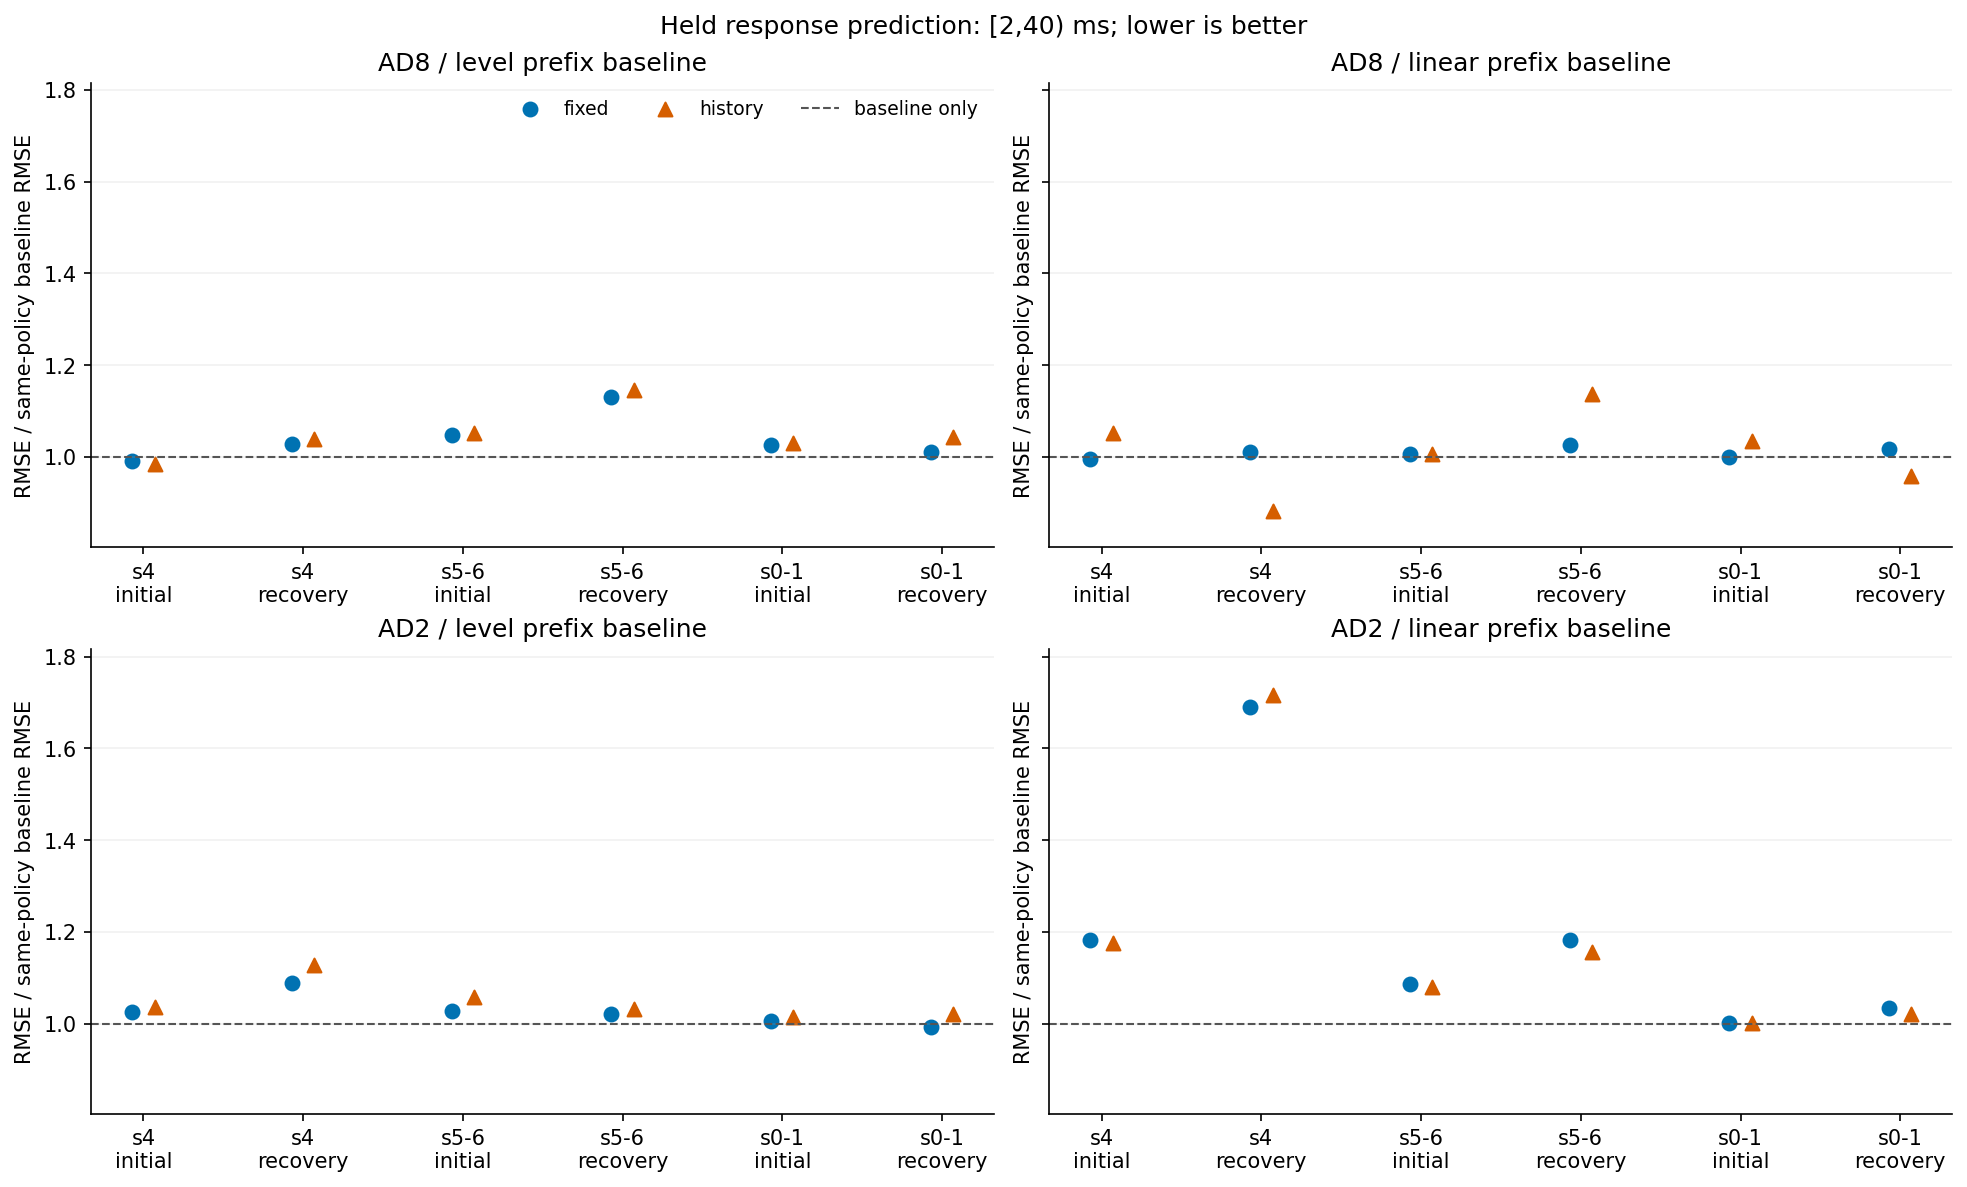

In [4]:
conditions = [(c,r) for c in ('later_same_command','later_sweeps_5_6','earlier_lower_source_command') for r in ('initial','recovery')]
labels = ['s4\ninitial','s4\nrecovery','s5-6\ninitial','s5-6\nrecovery','s0-1\ninitial','s0-1\nrecovery']
fig,axes = plt.subplots(2,2,figsize=(13,7.8),sharey=True,layout='constrained')
all_ratios = []
for row,target in enumerate(('positive','negative')):
    for col,policy in enumerate(('level','linear')):
        ax = axes[row,col]
        for method,color,marker,offset in (('fixed','#0072B2','o',-.07),('history','#D55E00','^',.07)):
            ratios = [score(target,policy,method,c,r)/score(target,policy,'baseline',c,r) for c,r in conditions]
            all_ratios.extend(ratios)
            ax.scatter(np.arange(6)+offset,ratios,c=color,marker=marker,s=44,label=method)
        ax.axhline(1,color='#555555',ls='--',lw=1,label='baseline only')
        ax.set_xticks(range(6),labels)
        ax.set_title(('AD8' if target=='positive' else 'AD2')+' / '+policy+' prefix baseline')
        ax.set_ylabel('RMSE / same-policy baseline RMSE')
        ax.grid(axis='y',alpha=.18)
axes[0,0].legend(frameon=False,ncol=3,fontsize=9)
lo,hi = min(all_ratios+[1]),max(all_ratios+[1])
axes[0,0].set_ylim(max(0,lo-.08),hi+.10)
fig.suptitle('Held response prediction: [2,40) ms; lower is better')
path = figures/'vc20hz_history_holdout.png'
fig.savefig(path,dpi=150,bbox_inches='tight')
display(Image(filename=str(path)))
plt.close(fig)


## 해석과 다음 판별
큰 명령 경계 반응은 존재하지만, 경계 이후의 조건부 전류 예측에서 이력 항의 우위는
조건·관측 정책·회복 구간에 따라 유지되지 않는다. 선형 기준선에서 개선된 칸도
일정 수준 기준선의 더 작은 오차를 넘어섰다는 뜻은 아니다. 네 선택이 모두50ms 하한에
있으므로 이를 실제 막 시정수나 시냅스 회복 상수로 채택하지 않는다.

Local baseline은 자기 자극 잔류를 완전히 설명한 측정모형이 아니다. Source AP 미관측,
작은 반복 수, 명령 조건과 시행 순서의 결합, 이진 연결 표적 표기의 한계를 유지한다.
이 코호트에서 모형 격자를 계속 늘려 가소성·계량을 확정하지 않는다. 다음 강한 판별은
source AP와 target current, 동시 측정 상태를 함께 관측한 자료에서 이력 항을 예측하는 것이다.
해마의 내용 전이·사건 구별 결과와의 전기적 연결은 여전히 별도 검증 대상이다.

## 재현
부모 JSON·raw NPZ·예측 NPZ의 해시를 위에서 대조했다. 이 notebook은 저장 예측의
검산과 그림만 수행한다. 모형 소스·검사·정확한 분할은 결과 JSON에 고정되어 있다.
Python은 보존 정책 실행기를 사용하며, notebook/Matplotlib 의존성은 기존 Temp 설치를 재사용한다.
